# Notebook Overview

This notebook was originally designed for **multi-node experiments**. For users who do not have a multi-node environment or want quick visualization, we provide a **single-machine, multi-process** version.

The core logic is identical to the multi-node implementation, except for process launching.

---

## Communication

Thanks to our custom communication framework:

- Multi-process workers communicate over **TCP loopback (127.0.0.1)**  
- The same networking stack is used as in the multi-node version  

This makes the notebook a faithful stand-in for real distributed runs.

---

## Multi-Node Version

For multi-node experiments, use the scripts in:

```text
examples/multi_node
```

# 1. Basic parameters

In [1]:
import pathlib

import ray
import numpy as np
import numpy.typing as npt

N_STATE = 20
N_ITER = 200
ALPHA = 0.3
EXP_NAME = "random"
ROOT_PATH = pathlib.Path.cwd().parent.parent
FIGURE_PATH = ROOT_PATH / "figures" / "small_scale" / EXP_NAME
FIGURE_PATH.mkdir(parents=True, exist_ok=True)

2026-02-19 19:06:08,360	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


# 2. Define the graph topology

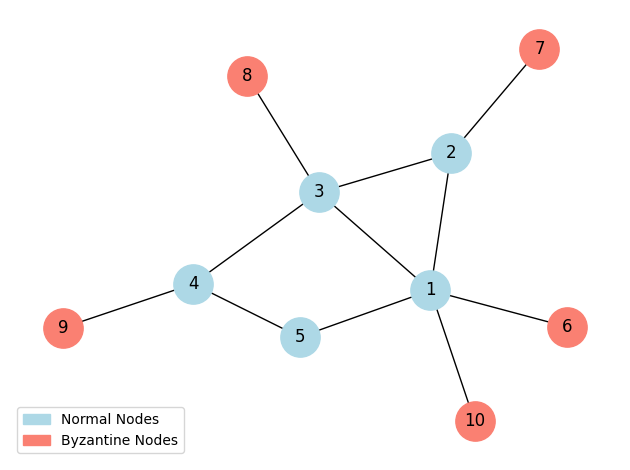

In [2]:
NORMAL_NODES = ["1", "2", "3", "4", "5"]
NORMAL_EDGES = [
    ("1", "2"),
    ("2", "3"),
    ("3", "4"),
    ("4", "5"),
    ("5", "1"),
    ("1", "3"),
]
BYZANTINE_NODES = ["6", "7", "8", "9", "10"]
BYZANTINE_EDGES = [("1", "6"), ("2", "7"), ("3", "8"), ("4", "9"), ("1", "10")]

NODES = NORMAL_NODES + BYZANTINE_NODES
EDGES = NORMAL_EDGES + BYZANTINE_EDGES

N_NORMAL = len(NORMAL_NODES)
N_BYZANTINE = len(BYZANTINE_NODES)
N_NODES = N_NORMAL + N_BYZANTINE

import matplotlib.pyplot as plt
import networkx as nx

fig, ax = plt.subplots()

G = nx.Graph()
G.add_nodes_from(NODES)
G.add_edges_from(EDGES)

pos = nx.spring_layout(G, seed=11, k=0.8)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=NORMAL_NODES,
    node_color="lightblue",
    node_size=800,
    ax=ax,
)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=BYZANTINE_NODES,
    node_color="salmon",
    node_size=800,
    ax=ax,
)

nx.draw_networkx_edges(G, pos, ax=ax)
nx.draw_networkx_labels(G, pos, ax=ax)

import matplotlib.patches as mpatches

blue_patch = mpatches.Patch(color="lightblue", label="Normal Nodes")
red_patch = mpatches.Patch(color="salmon", label="Byzantine Nodes")

ax.legend(handles=[blue_patch, red_patch], loc="lower left")
ax.axis("off")
plt.tight_layout()

fig.savefig(FIGURE_PATH / "network_topology.pdf", format="pdf")

import logging

logging.basicConfig(level=logging.INFO)

from conops import Graph, bootstrap

graph = Graph(NODES, EDGES)

# 3. Attacker model

In [3]:
@ray.remote(num_cpus=1)
def byzantine_node(
    name: str, n_state: int, alpha: float, n_iter: int, exp_name: str
) -> None:
    from numpy.random import seed, uniform
    from conops import NodeHandle

    nh = NodeHandle(name, transport="tcp")

    seed(int(name))  # Ensure reproducibility for each node

    for _ in range(n_iter - 1):
        attack_value = uniform(-100, 100, n_state)
        _ = nh.laplacian(attack_value)

# 4. Standard consensus
## (1) Run the algorithm

In [5]:
@ray.remote(num_cpus=1)
def baseline_node(
    name: str, n_state: int, alpha: float, n_iter: int
) -> npt.NDArray[np.float64]:
    lower_bound = -100.0
    upper_bound = 100.0

    from numpy import zeros
    from numpy.random import uniform, seed
    from conops import NodeHandle

    nh = NodeHandle(name, transport="tcp")

    x = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    x[0] = uniform(lower_bound, upper_bound, n_state)

    for k in range(n_iter - 1):
        x[k + 1] = x[k] - nh.laplacian(x[k]) * alpha

    return x


ray.init(address="auto")

try:
    bootstrap(graph)

    bl_refs = {i: baseline_node.remote(i, N_STATE, ALPHA, N_ITER) for i in NORMAL_NODES}

    byz_refs = [
        byzantine_node.remote(i, N_STATE, ALPHA, N_ITER, EXP_NAME)
        for i in BYZANTINE_NODES
    ]

    bl_data = {i: ray.get(ref) for i, ref in bl_refs.items()}
    ray.wait(byz_refs)

finally:
    ray.shutdown()

2026-02-19 19:06:34,531	INFO worker.py:1810 -- Connecting to existing Ray cluster at address: 192.168.1.112:6379...
2026-02-19 19:06:34,538	INFO worker.py:2004 -- Connected to Ray cluster. View the dashboard at 127.0.0.1:8265 
INFO:conops.bootstrap:Graph 'default' running on: 192.168.1.112:45123
INFO:conops.discovery:Registered graph service with name 'default'
INFO:conops.bootstrap:Node '6' joined graph 'default' from 192.168.1.112:46035.
INFO:conops.bootstrap:Node '7' joined graph 'default' from 192.168.1.111:39289.
INFO:conops.bootstrap:Node '3' joined graph 'default' from 192.168.1.103:39633.
INFO:conops.bootstrap:Node '8' joined graph 'default' from 192.168.1.107:38025.
INFO:conops.bootstrap:Node '10' joined graph 'default' from 192.168.1.106:41429.
INFO:conops.bootstrap:Node '9' joined graph 'default' from 192.168.1.108:45853.
INFO:conops.bootstrap:Node '4' joined graph 'default' from 192.168.1.109:38875.
INFO:conops.bootstrap:Node '1' joined graph 'default' from 192.168.1.110:46

## 

## (2) Visualize the Results

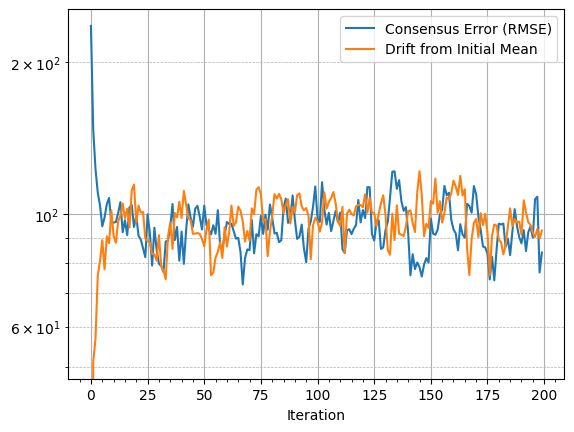

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

bl_states = np.array([bl_data[i] for i in NORMAL_NODES])
avg_states: npt.NDArray[np.float64] = np.average(bl_states, axis=0)
diffs = bl_states - avg_states
bl_rmse = np.sqrt(np.mean(np.sum(diffs**2, axis=2), axis=0))

x0_mean = avg_states[0]
bl_drift = np.linalg.norm(avg_states - x0_mean[None, :], axis=1)

ax.semilogy(bl_rmse, label="Consensus Error (RMSE)")
ax.semilogy(bl_drift, label="Drift from Initial Mean")

ax.set_xlabel("Iteration")
ax.minorticks_on()
ax.grid(which="major", linestyle="-", linewidth=0.8)
ax.grid(which="minor", axis="y", linestyle="--", linewidth=0.5)
ax.legend()

# 5. ARepC
## (1) Run the algorithm

In [24]:
@ray.remote(num_cpus=1)
def arepc_node(
    name: str,
    n_state: int,
    alpha: float,
    n_iter: int,
) -> tuple[npt.NDArray[np.float64], dict[str, npt.NDArray[np.float64]]]:
    lower_bound = -100.0
    upper_bound = 100.0

    from numpy import zeros
    from numpy.random import uniform, seed
    from conops import NodeHandle

    nh = NodeHandle(name, transport="tcp")

    from arepc import ARepC

    agent = ARepC(nh, alpha, eta=0.2)

    x = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    x[0] = uniform(lower_bound, upper_bound, n_state)

    reps = {neighbor: zeros(n_iter - 1) for neighbor in nh.neighbors}

    for k in range(n_iter - 1):
        # Compute new state
        x[k + 1] = agent.weighted_mix(x[k])

        # Record normalized weights history
        r = agent.reputations
        for j in nh.neighbors:
            reps[j][k] = r[j]

    return x, reps


ray.init(address="auto")

try:
    bootstrap(graph)

    arepc_refs = {i: arepc_node.remote(i, N_STATE, ALPHA, N_ITER) for i in NORMAL_NODES}
    byz_refs = [
        byzantine_node.remote(i, N_STATE, ALPHA, N_ITER, EXP_NAME)
        for i in BYZANTINE_NODES
    ]

    arepc_data = {i: ray.get(ref) for i, ref in arepc_refs.items()}
    ray.wait(byz_refs)

finally:
    ray.shutdown()

2026-02-19 19:09:44,915	INFO worker.py:1810 -- Connecting to existing Ray cluster at address: 192.168.1.112:6379...
2026-02-19 19:09:44,924	INFO worker.py:2004 -- Connected to Ray cluster. View the dashboard at 127.0.0.1:8265 
INFO:conops.bootstrap:Graph 'default' running on: 192.168.1.112:45235
INFO:conops.discovery:Registered graph service with name 'default'
INFO:conops.bootstrap:Node '6' joined graph 'default' from 192.168.1.112:45735.
INFO:conops.bootstrap:Node '7' joined graph 'default' from 192.168.1.111:32967.
INFO:conops.bootstrap:Node '10' joined graph 'default' from 192.168.1.108:34287.
INFO:conops.bootstrap:Node '2' joined graph 'default' from 192.168.1.103:44469.
INFO:conops.bootstrap:Node '1' joined graph 'default' from 192.168.1.109:40859.
INFO:conops.bootstrap:Node '8' joined graph 'default' from 192.168.1.106:34465.
INFO:conops.bootstrap:Node '4' joined graph 'default' from 192.168.1.104:41319.
INFO:conops.bootstrap:Node '3' joined graph 'default' from 192.168.1.105:33

## (2) Visualize the Results
### I. State

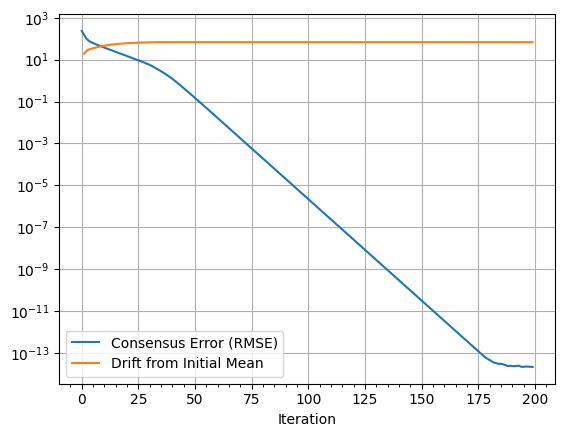

In [51]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

iters = np.arange(N_ITER)

arepc_states = np.array([arepc_data[i][0] for i in NORMAL_NODES])
avg_states: npt.NDArray[np.float64] = np.average(arepc_states, axis=0)
diffs = arepc_states - avg_states
aprec_rmse = np.sqrt(np.mean(np.sum(diffs**2, axis=2), axis=0))

x0_mean = avg_states[0]
aprec_drift = np.linalg.norm(avg_states - x0_mean[None, :], axis=1)

ax.semilogy(iters, aprec_rmse, label="Consensus Error (RMSE)")
ax.semilogy(iters[1:], aprec_drift[1:], label="Drift from Initial Mean")

ax.legend()
ax.set_xlabel("Iteration")
ax.minorticks_on()
ax.grid(which="major", linestyle="-", linewidth=0.8)
ax.grid(which="minor", axis="y", linestyle="--", linewidth=0.5)

### II. Reputation

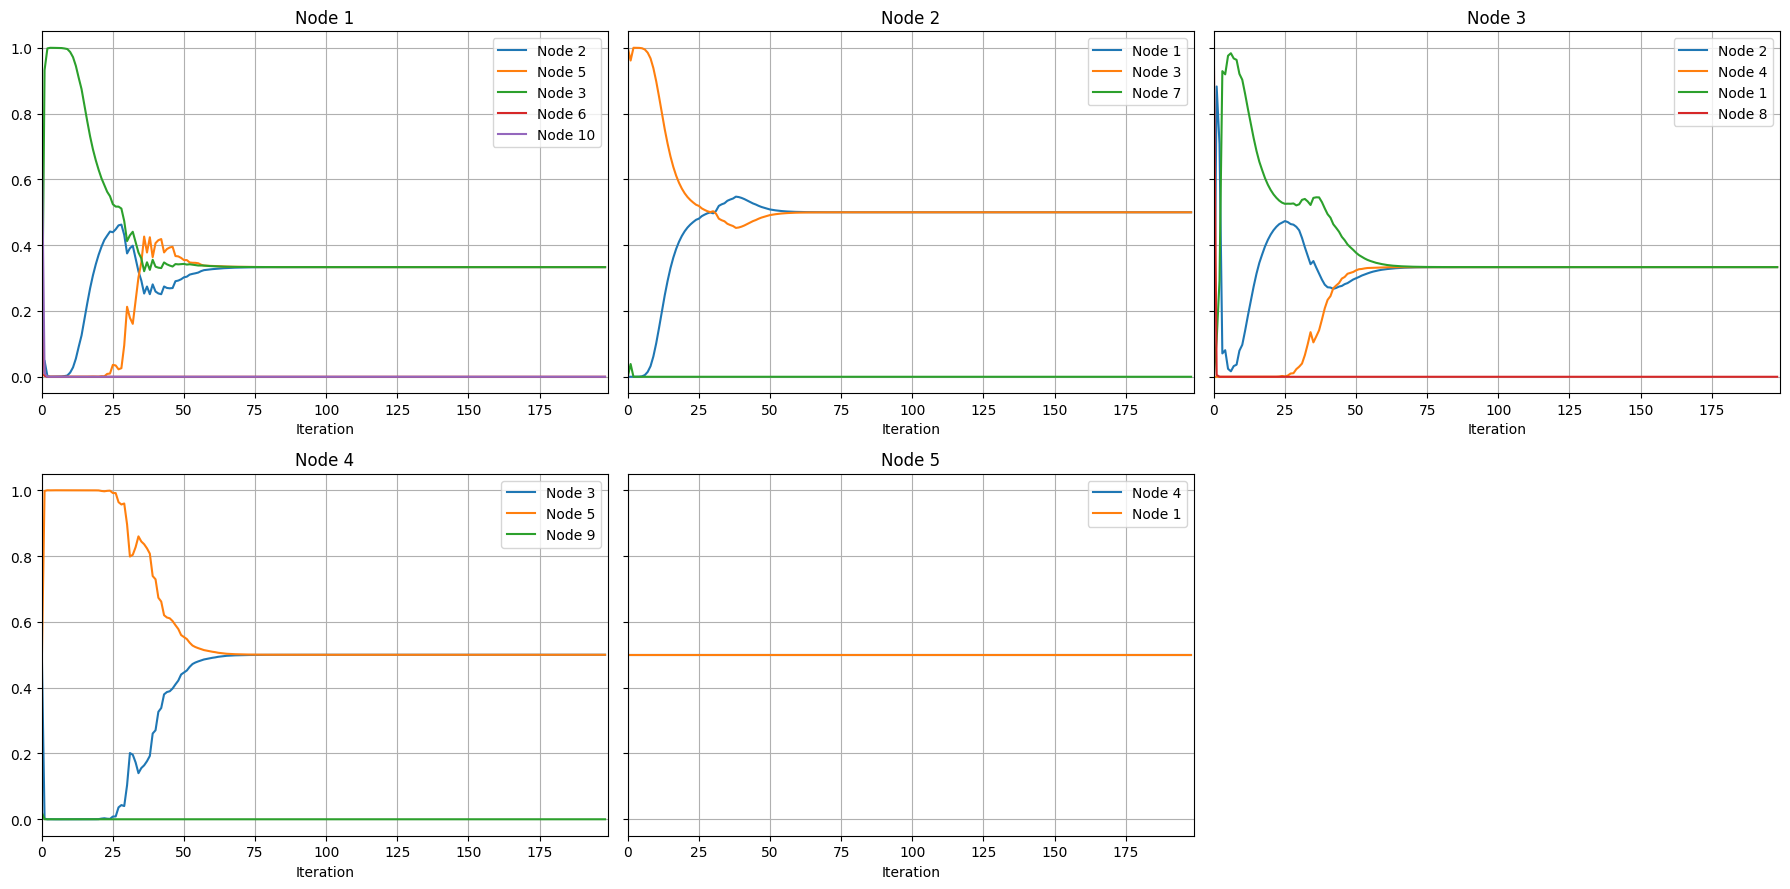

In [40]:
import matplotlib.axes as maxes

axes: npt.NDArray
fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharey=True)
axes_flat = axes.flatten()

repc_reps = {i: arepc_data[i][1] for i in NORMAL_NODES}

for i, ax in zip(NORMAL_NODES, axes_flat[:-1]):
    ax: maxes.Axes
    reps_for_i = repc_reps[i]
    for j in reps_for_i:
        ax.plot(reps_for_i[j], label=f"Node {j}")
    ax.set_title(f"Node {i}")
    ax.set_xlabel("Iteration")
    ax.set_xlim(0, N_ITER - 1)
    ax.legend()
    ax.grid()

fig.delaxes(axes_flat[-1])
fig.tight_layout()

# 6. RepC
## (1) Run the algorithm

In [16]:
@ray.remote(num_cpus=1)
def repc_node(
    name: str, n_state: int, alpha: float, n_iter: int
) -> tuple[npt.NDArray[np.float64], dict[str, npt.NDArray[np.float64]]]:
    lower_bound = -100.0
    upper_bound = 100.0

    from conops import NodeHandle

    nh = NodeHandle(name, transport="tcp")

    from arepc.baselines import RepC

    agent = RepC(nh, alpha, f=1)

    from numpy import zeros
    from numpy.random import uniform, seed

    states = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    states[0] = uniform(lower_bound, upper_bound, n_state)

    reps = {neighbor: zeros(n_iter - 1) for neighbor in nh.neighbors}

    for k in range(n_iter - 1):
        # Compute new state
        states[k + 1] = agent.weighted_mix(states[k])

        # Record normalized weights history
        r = agent.reputations
        for j in nh.neighbors:
            reps[j][k] = r[j]

    return states, reps


ray.init(address="auto")

try:
    bootstrap(graph)

    repc_refs = {i: repc_node.remote(i, N_STATE, ALPHA, N_ITER) for i in NORMAL_NODES}
    byz_refs = [
        byzantine_node.remote(i, N_STATE, ALPHA, N_ITER, EXP_NAME)
        for i in BYZANTINE_NODES
    ]

    repc_data = {i: ray.get(ref) for i, ref in repc_refs.items()}
    ray.wait(byz_refs)

finally:
    ray.shutdown()

2026-02-19 19:08:42,427	INFO worker.py:1810 -- Connecting to existing Ray cluster at address: 192.168.1.112:6379...
2026-02-19 19:08:42,434	INFO worker.py:2004 -- Connected to Ray cluster. View the dashboard at 127.0.0.1:8265 
INFO:conops.bootstrap:Graph 'default' running on: 192.168.1.112:45771
INFO:conops.discovery:Registered graph service with name 'default'
INFO:conops.bootstrap:Node '6' joined graph 'default' from 192.168.1.111:41583.
INFO:conops.bootstrap:Node '7' joined graph 'default' from 192.168.1.112:45335.
INFO:conops.bootstrap:Node '2' joined graph 'default' from 192.168.1.105:36849.
INFO:conops.bootstrap:Node '8' joined graph 'default' from 192.168.1.103:43997.
INFO:conops.bootstrap:Node '10' joined graph 'default' from 192.168.1.106:36451.
INFO:conops.bootstrap:Node '9' joined graph 'default' from 192.168.1.108:38537.
INFO:conops.bootstrap:Node '5' joined graph 'default' from 192.168.1.109:42943.
INFO:conops.bootstrap:Node '1' joined graph 'default' from 192.168.1.107:38

## (2) Visualize the Results
### I. State

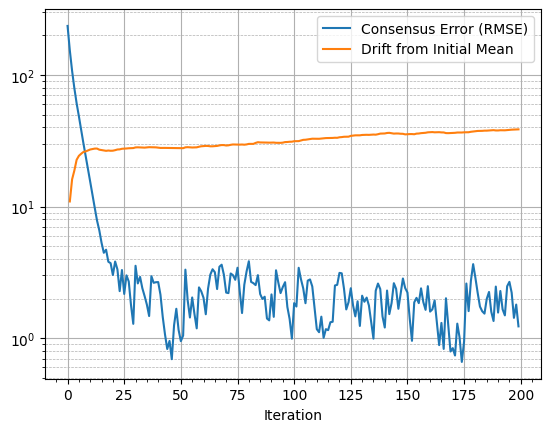

In [50]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

iters = np.arange(N_ITER)

repc_states = np.array([repc_data[i][0] for i in NORMAL_NODES])
avg_states: npt.NDArray[np.float64] = np.average(repc_states, axis=0)
diffs = repc_states - avg_states
repc_rmse = np.sqrt(np.mean(np.sum(diffs**2, axis=2), axis=0))

x0_mean = avg_states[0]
repc_drift = np.linalg.norm(avg_states - x0_mean[None, :], axis=1)

ax.semilogy(iters, repc_rmse, label="Consensus Error (RMSE)")
ax.semilogy(iters[1:], repc_drift[1:], label="Drift from Initial Mean")

ax.legend()
ax.set_xlabel("Iteration")
ax.minorticks_on()
ax.grid(which="major", linestyle="-", linewidth=0.8)
ax.grid(which="minor", axis="y", linestyle="--", linewidth=0.5)

### II. Reputation

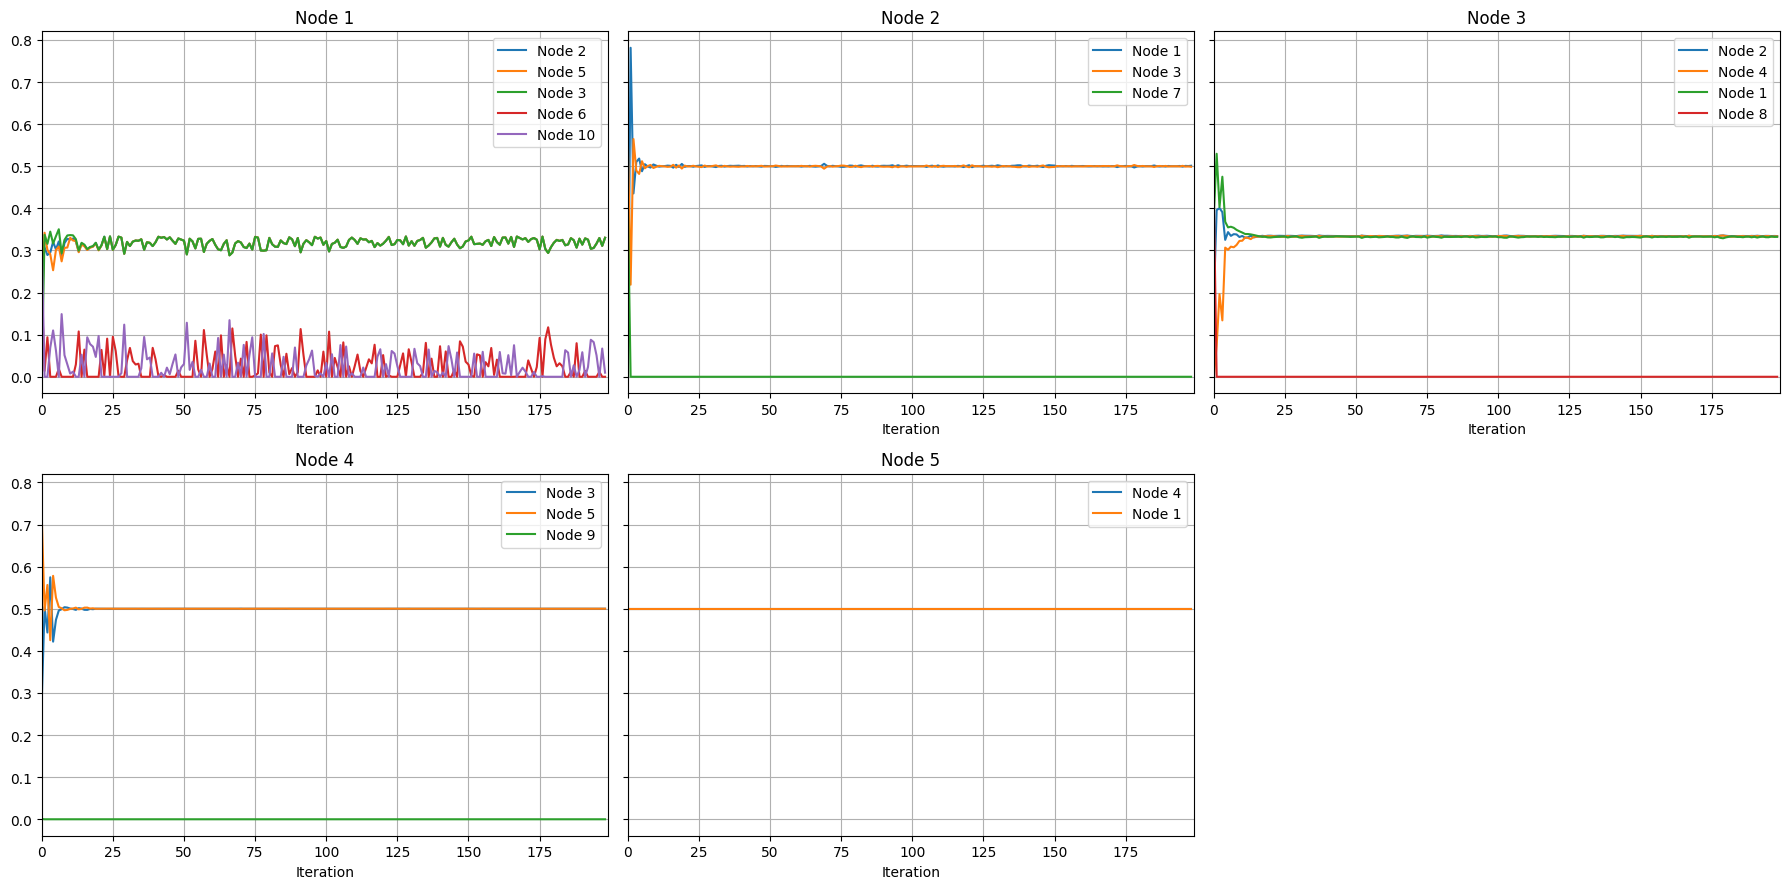

In [37]:
axes: npt.NDArray
fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharey=True)
axes_flat = axes.flatten()

repc_reps = {i: repc_data[i][1] for i in NORMAL_NODES}

for i, ax in zip(NORMAL_NODES, axes_flat[:-1]):
    ax: maxes.Axes
    reps_for_i = repc_reps[i]
    for j in reps_for_i:
        ax.plot(reps_for_i[j], label=f"Node {j}")
    ax.set_title(f"Node {i}")
    ax.set_xlabel("Iteration")
    ax.set_xlim(0, N_ITER - 1)
    ax.legend()
    ax.grid()

fig.delaxes(axes_flat[-1])
fig.tight_layout()

# 7. W-MSR
## (1) Run the algorithm

In [20]:
@ray.remote(num_cpus=1)
def wmsr_node(
    name: str, n_state: int, alpha: float, n_iter: int
) -> npt.NDArray[np.float64]:
    lower_bound = -100.0
    upper_bound = 100.0

    from conops import NodeHandle

    nh = NodeHandle(name, transport="tcp")

    from arepc.baselines import WMSR

    agent = WMSR(nh, alpha, f=1)

    from numpy import zeros
    from numpy.random import uniform, seed

    states = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    states[0] = uniform(lower_bound, upper_bound, n_state)

    for k in range(n_iter - 1):
        # Compute new state
        states[k + 1] = agent.weighted_mix(states[k])

    return states


ray.init(address="auto")

try:
    bootstrap(graph)

    wmsr_refs = {i: wmsr_node.remote(i, N_STATE, ALPHA, N_ITER) for i in NORMAL_NODES}
    byz_refs = [
        byzantine_node.remote(i, N_STATE, ALPHA, N_ITER, EXP_NAME)
        for i in BYZANTINE_NODES
    ]

    wmsr_data = {i: ray.get(ref) for i, ref in wmsr_refs.items()}
    ray.wait(byz_refs)

finally:
    ray.shutdown()

2026-02-19 19:09:06,527	INFO worker.py:1810 -- Connecting to existing Ray cluster at address: 192.168.1.112:6379...
2026-02-19 19:09:06,535	INFO worker.py:2004 -- Connected to Ray cluster. View the dashboard at 127.0.0.1:8265 
INFO:conops.bootstrap:Graph 'default' running on: 192.168.1.112:46395
INFO:conops.discovery:Registered graph service with name 'default'
INFO:conops.bootstrap:Node '6' joined graph 'default' from 192.168.1.112:45717.
INFO:conops.bootstrap:Node '7' joined graph 'default' from 192.168.1.111:41687.
INFO:conops.bootstrap:Node '5' joined graph 'default' from 192.168.1.103:41377.
INFO:conops.bootstrap:Node '3' joined graph 'default' from 192.168.1.110:36287.
INFO:conops.bootstrap:Node '1' joined graph 'default' from 192.168.1.105:43615.
INFO:conops.bootstrap:Node '9' joined graph 'default' from 192.168.1.107:32773.
INFO:conops.bootstrap:Node '10' joined graph 'default' from 192.168.1.106:41483.
INFO:conops.bootstrap:Node '8' joined graph 'default' from 192.168.1.108:44

## (2) Visualize the Results

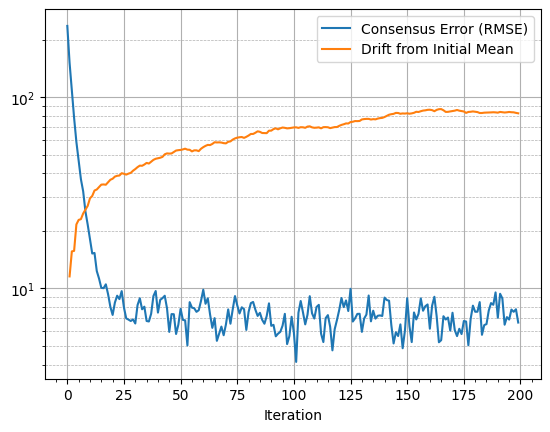

In [49]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

iters = np.arange(N_ITER)

wmsr_states = np.array([wmsr_data[i] for i in NORMAL_NODES])
avg_states: npt.NDArray[np.float64] = np.average(wmsr_states, axis=0)
diffs = wmsr_states - avg_states
wmsr_rmse = np.sqrt(np.mean(np.sum(diffs**2, axis=2), axis=0))

x0_mean = avg_states[0]
wmsr_drift = np.linalg.norm(avg_states - x0_mean[None, :], axis=1)

ax.semilogy(iters, wmsr_rmse, label="Consensus Error (RMSE)")
ax.semilogy(iters[1:], wmsr_drift[1:], label="Drift from Initial Mean")

ax.legend()
ax.set_xlabel("Iteration")
ax.minorticks_on()
ax.grid(which="major", linestyle="-", linewidth=0.8)
ax.grid(which="minor", axis="y", linestyle="--", linewidth=0.5)

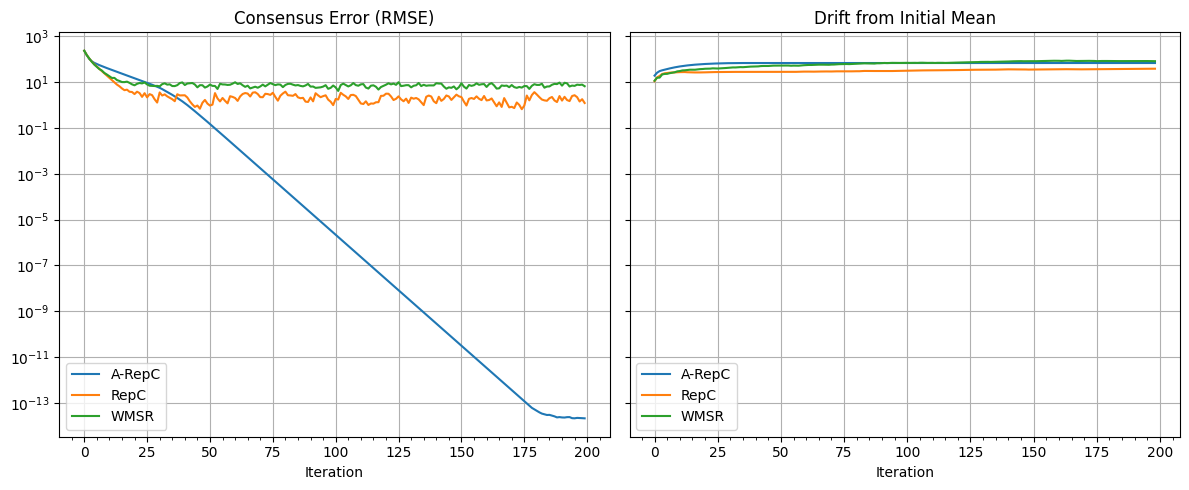

In [55]:
import typing as tp
import matplotlib.axes as maxes

axes: tp.Sequence[maxes.Axes]
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].semilogy(iters, aprec_rmse, label="A-RepC")
axes[0].semilogy(iters, repc_rmse, label="RepC")
axes[0].semilogy(iters, wmsr_rmse, label="WMSR")
axes[0].set_xlabel("Iteration")
axes[0].set_title("Consensus Error (RMSE)")
axes[0].legend()
axes[0].minorticks_on()
axes[0].grid(which="major", linestyle="-", linewidth=0.8)
axes[0].grid(which="minor", axis="y", linestyle="--", linewidth=0.5)

axes[1].semilogy(aprec_drift[1:], label="A-RepC")
axes[1].semilogy(repc_drift[1:], label="RepC")
axes[1].semilogy(wmsr_drift[1:], label="WMSR")
axes[1].set_xlabel("Iteration")
axes[1].set_title("Drift from Initial Mean")
axes[1].legend()
axes[1].minorticks_on()
axes[1].grid(which="major", linestyle="-", linewidth=0.8)
axes[1].grid(which="minor", axis="y", linestyle="--", linewidth=0.5)

fig.tight_layout()